문제처리 방식

1. 미션 소개 (문제 정의 및 목표 설정)
2. 기본 데이터 입력 및 EDA
3. 전처리 및 증강
4. 드릴 다운 (할 수 있는게 있다면?)
5. 모델링
6. 결과 시각화 (Feature Importance)
7. 결과 생성

In [ ]:
import torch

device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"device : {device}")


device : mps


# 01. 🩺 미션 소개: GURU  (이진 분류)

이번 미션에서는 **흉부 X-Ray 사진**을 바탕으로 **폐렴 환자를 구분**하는 작업을 수행합니다.  
목표는 **X-Ray 이미지를 입력으로 받아 폐렴 여부를 분류(Classification)** 하는 모델을 만드는 것입니다.  

아래 데이터셋을 활용하여 **다양한 이미지 전처리 및 증강 기법**, 그리고 **Transfer Learning & Fine-Tuning 기법**을 실험해보고 모델 성능을 평가해 보세요.  

---

## 📂 데이터 소개
- **데이터 링크**: [Chest X-Ray Images (Pneumonia)](링크)  
- 데이터 구성:
  - `train`: 훈련 데이터
  - `test`: 테스트 데이터
  - `val`: 검증 데이터

---

## 📌 제출 안내
- **제출 파일**: Colab Notebook (`.ipynb`)  
- **파일명 형식**: `06_{팀명}_{성함}.ipynb`  

---

## ✅ 분석 과정 및 결과 포함 사항
1. **데이터 로드 및 전처리**  
2. **모델 학습**  
3. **예측 및 성능 평가**  
4. **Transfer Learning 적용**  
5. **Fine-Tuning 적용**  
   - Frozen 모델  
   - Partial Fine-Tuning  
   - Full Fine-Tuning  
6. **모델별 성능 비교 및 결과 분석**  
7. **마크다운을 활용한 단계별 설명**

---

## 🖊️ 마크다운 작성 가이드
- 코드 각 단계에 대해 **무엇을, 왜 수행하는지** 설명을 명확히 작성하세요.  
- 코드와 실행 결과에 대한 **해석 문구**를 추가하세요.  
- 별도의 보고서를 작성하지 않으므로, **노트북 내에서 모든 설명이 잘 드러나야 합니다.**

---

## 📊 모델 성능 평가 및 제출
- **평가 지표**: Accuracy, Precision, Recall, F1-score  
- **테스트 데이터**를 활용하여 최종 모델 성능 평가  
- **모델별 성능 평가 결과**를 포함한 노트북 제출  

---

## 💡 참고 사항
- **Baseline 코드**가 제공됩니다.  
  - 시작할 때 참고 가능  
  - 단순 복사보다는 **자신만의 아이디어를 추가**하여 성능을 발전시키는 것이 중요합니다.  
- 권장: 스스로 모델을 구축하고 다양한 방법을 시도해 성능을 향상시켜 보세요.  

In [ ]:
# 코드셀 1: 기본 환경 / 디바이스 설정
import os
import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision import transforms, datasets
from torchvision.utils import make_grid
from PIL import Image

# scikit-learn은 EDA/평가에 유용
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("PyTorch:", torch.__version__, "Torchvision:", torchvision.__version__)

PyTorch: 2.8.0 Torchvision: 0.23.0


# 02. 기본 데이터 입력 및 EDA

In [ ]:
#데이터 입력

DATA_DIR = Path("")

def count_images(root: Path):
    stats = {}
    for split in ['train', 'val', 'test']:
        split_dir = root / split
        if not split_dir.exists():
            continue
        counts = {}
        for class_dir in split_dir.iterdir():
            if class_dir.is_dir():
                counts[class_dir.name] = sum(1 for _ in class_dir.glob("*.jpeg")) + sum(1 for _ in class_dir.glob("*.jpg")) + sum(1 for _ in class_dir.glob("*.png"))
        stats[split] = counts
    return stats

stats = count_images(DATA_DIR)
stats

{'train': {'PNEUMONIA': 3875, 'NORMAL': 1341},
 'val': {'PNEUMONIA': 8, 'NORMAL': 8},
 'test': {'PNEUMONIA': 390, 'NORMAL': 234}}

- Train 한쪽으로 데이터가 너무 치우쳐져있다면, 편향이 발생할 수 있음

In [ ]:
train_dir = "train"  # 데이터셋 경로
val_dir = "val"  # 데이터셋 경로
test_dir = "test"  # 데이터셋 경로

train_normal_dir = os.path.join(train_dir, 'NORMAL')
train_pneumonia_dir = os.path.join(train_dir, 'PNEUMONIA')

valid_normal_dir = os.path.join(val_dir, 'NORMAL')
valid_pneumonia_dir = os.path.join(val_dir, 'PNEUMONIA')

test_normal_dir = os.path.join(test_dir, 'NORMAL')
test_pneumonia_dir = os.path.join(test_dir, 'PNEUMONIA')

# 03. 전처리 및 증강


In [ ]:
import cv2

# 사진의 전처리를 위해, 사진을 불러오는 파일을 만들고, 샘플이미지를 만들어보자
# 전체 사진 파일 불러오기
def load_images(folder):
    images = []
    for filename in os.listdir(folder):
        if filename.endswith(".jpeg"):  # PNG 파일만 가져오기
            img_path = os.path.join(folder, filename)
            img = cv2.imread(img_path)  # OpenCV로 이미지를 읽음 (BGR 형식)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR → RGB 변환
            images.append(img)
    return images

# 샘플 이미지 불러오기
train = load_images(train_normal_dir) + load_images(train_pneumonia_dir)
valid = load_images(valid_normal_dir) + load_images(valid_pneumonia_dir)
test = load_images(test_normal_dir) + load_images(test_pneumonia_dir)

In [ ]:
# train, valid, test 리스트에 들어있는 이미지의 개수 확인
print(f"훈련 이미지 개수: {len(train)}")
print(f"검증 이미지 개수: {len(valid)}")
print(f"테스트 이미지 개수: {len(test)}")

print("-" * 20)

# 첫 번째 훈련 이미지의 정보 확인
if train:  # train 리스트가 비어있지 않은지 확인
    print(f"첫 번째 이미지의 자료형: {type(train[0])}")
    print(f"첫 번째 이미지의 형태(shape): {train[0].shape}") # (세로, 가로, 채널)
    print(f"첫 번째 이미지의 데이터 타입(dtype): {train[0].dtype}")

훈련 이미지 개수: 5216
검증 이미지 개수: 16
테스트 이미지 개수: 624
--------------------
첫 번째 이미지의 자료형: <class 'numpy.ndarray'>
첫 번째 이미지의 형태(shape): (2234, 2359, 3)
첫 번째 이미지의 데이터 타입(dtype): uint8


In [ ]:
# 이미지 크기 확인
import numpy as np

# 각 데이터셋의 이미지 크기 추출
train_sizes = [img.shape[:2] for img in train]  # train 이미지의 크기 (height, width)
valid_sizes = [img.shape[:2] for img in valid]  # cleaned 이미지의 크기
test_sizes = [img.shape[:2] for img in test]  # test 이미지의 크기

# 유니크한 이미지 크기 계산
train_unique_sizes = np.unique(train_sizes, axis=0)  # train 이미지의 유니크 크기
train_cleaned_unique_sizes = np.unique(valid_sizes, axis=0)  # train_cleaned 유니크 크기
test_unique_sizes = np.unique(test_sizes, axis=0)  # test 유니크 크기

# 결과 출력
print("Unique sizes in train:\n", train_unique_sizes)
print("Unique sizes in train_cleaned:\n", train_cleaned_unique_sizes)
print("Unique sizes in test:\n", test_unique_sizes)

Unique sizes in train:
 [[ 127  384]
 [ 132  446]
 [ 138  400]
 ...
 [2625 2694]
 [2628 2619]
 [2663 2373]]
Unique sizes in train_cleaned:
 [[ 592  968]
 [ 656 1016]
 [ 664 1152]
 [ 712 1072]
 [ 864 1256]
 [ 928 1288]
 [ 944 1416]
 [ 952 1192]
 [1040 1272]
 [1104 1240]
 [1104 1328]
 [1128 1664]
 [1225 1632]
 [1302 1564]
 [1416 1736]
 [1416 1776]]
Unique sizes in test:
 [[ 344  888]
 [ 368  728]
 [ 416  744]
 ...
 [2382 2746]
 [2458 2720]
 [2713 2517]]


In [ ]:
# 파이토치의 이미지 변환 기능을 v2
from torchvision.transforms import v2

# 데이터 변환 규칙들을 딕셔너리 형태로 정의합니다.
data_transforms = {
    # 'train' 데이터에 적용할 변환 규칙들
    'train': v2.Compose([
        # 1. 이미지 크기를 224x224로 통일합니다. 모델에 입력되는 이미지 크기는 모두 같아야 합니다.
        v2.Resize((224, 224)),
        # 2. 이미지를 좌우로 무작위로 뒤집습니다. 모델이 방향에 덜 민감해지도록 돕습니다.
        v2.RandomHorizontalFlip(),
        # 3. 이미지를 최대 10도까지 무작위로 회전시킵니다. 회전된 이미지에도 잘 반응하도록 훈련합니다.
        v2.RandomRotation(10),
        # 4. 이미지를 파이토치 텐서(Tensor) 형태로 변환합니다. 모델이 계산할 수 있는 숫자 행렬 형태입니다.
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        # 5. 이미지 픽셀 값을 -1에서 1 사이로 정규화합니다. 학습을 더 안정적이고 빠르게 만들어줍니다.
        # (평균 0.5, 표준편차 0.5를 기준으로 R, G, B 각 채널에 적용)
        v2.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
    # 'val'과 'test' 데이터에는 데이터 증강을 적용하지 않습니다.
    # 모델의 순수한 성능을 평가해야 하므로, 원본 이미지를 최소한으로 변환합니다.
    'val': v2.Compose([
        v2.Resize((224, 224)), # 크기 통일
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),        # 텐서로 변환
        v2.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) # 정규화
    ]),
    'test': v2.Compose([
        v2.Resize((224, 224)), # 크기 통일
        v2.ToImage(),                                  # 입력 데이터를 PyTorch에서 다룰 수 있는 이미지 객체로 변환합니다.
        v2.ToDtype(torch.float32, scale=True),         # 텐서로 변환 (scale=True 이므로 픽셀 값(0~255 범위)을 0~1 사이 값으로 정규화.)
        v2.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) # 정규화
    ])
}

## 2) 데이터셋 및 데이터로더 생성

In [ ]:
# 이미지 데이터셋과 데이터로더를 만들기 위한 기능들을 불러옵니다.
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

# 1. 원본 'train' 폴더의 모든 이미지를 불러와 하나의 큰 데이터셋으로 만듭니다.
# 이때, transform 인자에는 나중에 바꿀 것이므로 일단 검증용(val) 변환을 적용합니다.
full_train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['val'])
# 'test' 폴더의 이미지들도 데이터셋으로 만듭니다.
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['test'])

# 2. full_train_dataset을 학습용과 검증용으로 나눌 크기를 계산합니다.
n_samples = len(full_train_dataset) # 전체 샘플 수
train_size = int(n_samples * 0.8)   # 80%는 학습용
val_size = n_samples - train_size   # 나머지 20%는 검증용

# 3. random_split 함수로 데이터셋을 실제로 분리합니다.
train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])

# 4. 분리된 학습용(train_subset) 데이터셋에는 데이터 증강이 포함된 'train' 변환 규칙을 적용합니다.
# (검증용은 이미 'val' 규칙이 적용되어 있으므로 그대로 둡니다)
train_subset.dataset.transform = data_transforms['train']

# 5. 각 데이터셋을 DataLoader로 감싸줍니다.
# DataLoader는 데이터를 batch_size만큼 묶고, 학습 시 순서를 섞어주는(shuffle=True) 역할을 합니다.
batch_size = 32
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False) # 검증/테스트는 섞지 않습니다.
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 클래스 이름(폴더명)과 각 데이터셋의 크기를 확인합니다.
class_names = full_train_dataset.classes
print(f"클래스: {class_names}")
print(f"학습 데이터 수: {len(train_subset)}")
print(f"검증 데이터 수: {len(val_subset)}")
print(f"테스트 데이터 수: {len(test_dataset)}")

클래스: ['NORMAL', 'PNEUMONIA']
학습 데이터 수: 4172
검증 데이터 수: 1044
테스트 데이터 수: 624


## 3) 데이터 시각화 - 데이터가 잘 준비되었는지 먼저 확인

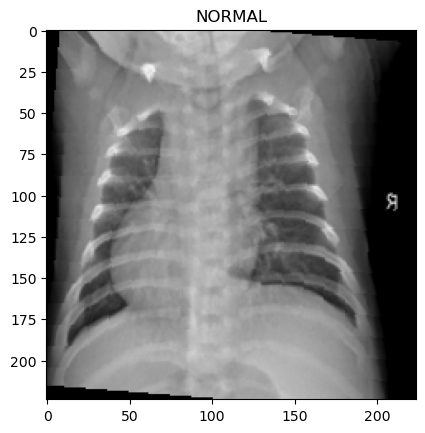

In [ ]:
# 시각화를 위한 라이브러리들을 불러옵니다.
import matplotlib.pyplot as plt
import numpy as np

# 데이터로더에서 이미지와 라벨 한 묶음(배치)을 꺼냅니다.
images, labels = next(iter(train_loader))

# 이미지를 화면에 보여주는 함수를 정의합니다.
def imshow(img, title):
    # 1. 정규화(-1~1)된 이미지 픽셀 값을 다시 0~1 범위로 되돌립니다.
    img = img / 2 + 0.5
    # 2. 파이토치 텐서를 numpy 배열로 변환합니다.
    npimg = img.numpy()
    # 3. 텐서의 차원 순서(채널, 높이, 너비)를 matplotlib이 이해하는 순서(높이, 너비, 채널)로 변경합니다.
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    # 4. 이미지의 제목(클래스 이름)을 설정합니다.
    plt.title(title)
    plt.show()

# 첫 번째 이미지와 라벨을 사용해 시각화 함수를 실행합니다.
# 데이터 증강 때문에 실행할 때마다 조금씩 다른 모습의 이미지가 보일 수 있습니다.
imshow(images[0], title=class_names[labels[0]])

# 04. 드릴 다운 (할 수 있는게 있다면?)

# 05. 모델링 & 시각화

## 1. CNN - Baseline

In [ ]:
import torch.optim as optim

# 클래스 수(NORMAL, PNEUMONIA)를 가져옵니다.
num_classes = len(class_names)

# 1. 모델 생성: 위에서 설계한 CustomCNN 클래스로 실제 모델 객체를 만듭니다.
# .to(device)를 통해 모델을 GPU나 CPU로 보냅니다.
model = CustomCNN(num_classes=num_classes).to(device)

# 2. 손실 함수 정의: 다중 분류 문제에 가장 널리 쓰이는 CrossEntropyLoss를 사용합니다.
# 모델의 예측 결과와 실제 정답 간의 차이를 계산해 줍니다.
loss_fn = nn.CrossEntropyLoss()

# 3. Adam 옵티마이저.
# model.parameters()를 전달하여 모델의 모든 학습 가능한 파라미터를 업데이트하도록 설정.
# lr=0.001은 학습률(learning rate)로, 가중치를 얼마나 크게 업데이트할지 결정하는 중요한 값.
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
from tqdm.auto import tqdm # 학습 진행 상황을 시각적으로 보여주는 라이브러리

def train_model(model, train_loader, val_loader, loss_fn, optimizer, num_epochs):
    # epoch만큼 학습을 반복합니다.
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # --- 훈련 단계 ---
        model.train() # 모델을 '학습 모드'로 설정합니다.
        running_loss = 0.0
        running_corrects = 0

        # 데이터로더에서 미니배치(데이터 묶음)를 하나씩 꺼내와 학습합니다.
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Train"):
            inputs = inputs.to(device)  # 데이터를 설정된 장치(GPU/CPU)로 보냅니다.
            labels = labels.to(device)

            optimizer.zero_grad() # 이전 배치의 그래디언트(기울기)를 초기화합니다.

            outputs = model(inputs) # 모델에 입력을 넣어 예측값을 얻습니다.
            loss = loss_fn(outputs, labels) # 예측값과 실제 정답으로 손실을 계산합니다.

            _, preds = torch.max(outputs, 1) # 예측 결과 중 가장 확률이 높은 클래스를 선택합니다.

            loss.backward() # 손실을 역전파하여 각 파라미터의 그래디언트를 계산합니다.
            optimizer.step() # 계산된 그래디언트를 바탕으로 파라미터를 업데이트합니다.

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # 한 epoch의 평균 손실과 정확도를 계산합니다.
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.float() / len(train_loader.dataset)

        # --- 검증 단계 ---
        model.eval() # 모델을 '평가 모드'로 설정합니다.
        val_loss = 0.0
        val_corrects = 0

        # 평가 시에는 그래디언트 계산을 비활성화하여 메모리 사용량과 계산 속도를 높입니다.
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Val"):
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = loss_fn(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        # 한 epoch의 평균 검증 손실과 정확도를 계산합니다.
        val_epoch_loss = val_loss / len(val_loader.dataset)
        val_epoch_acc = val_corrects.float() / len(val_loader.dataset)

        # 결과 출력
        print(f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}")
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_epoch_acc.item())

    return model, history

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# 'nn.Module'을 상속받아 우리만의 CNN 모델 클래스를 정의
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__() # nn.Module의 초기화 메서드를 먼저 호출합니다.

        # --- 특징 추출부 (Feature Extractor) ---
        # 첫 번째 합성곱 레이어: 3채널(RGB) 이미지를 입력으로 받아 16개의 특징 맵을 생성합니다.
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        # 두 번째 합성곱 레이어: 16개의 특징 맵을 입력으로 받아 32개의 더 복잡한 특징 맵을 만듭니다.
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # 맥스 풀링 레이어: 2x2 영역에서 가장 큰 값만 남겨 특징을 압축하고 이미지 크기를 절반으로 줄입니다.
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- 분류기 (Classifier) ---
        # 첫 번째 완전 연결 레이어(분류기): 압축된 특징 맵을 1차원 벡터로 펼친 후, 256개의 노드로 연결합니다.
        # 입력 크기 계산: 224x224 -> (pool) -> 112x112 -> (pool) -> 56x56. 최종 특징맵 수는 32개이므로,
        # 입력 뉴런 수는 32 * 56 * 56 = 100352 입니다.
        self.fc1 = nn.Linear(32 * 56 * 56, 256)

        # 두 번째 완전 연결 레이어(출력층): 256개 노드를 최종 클래스 수(PNEUMONIA, NORMAL -> 2개)로 연결합니다.
        self.fc2 = nn.Linear(256, num_classes)

    # 데이터가 모델을 통과하는 흐름(순서)을 정의합니다.
    def forward(self, x):
        # x의 초기 크기: [배치 크기, 3, 224, 224]

        # 1. conv1 -> ReLU 활성화 함수 -> pool
        x = self.pool(F.relu(self.conv1(x)))
        # x의 크기: [배치 크기, 16, 112, 112]

        # 2. conv2 -> ReLU 활성화 함수 -> pool
        x = self.pool(F.relu(self.conv2(x)))
        # x의 크기: [배치 크기, 32, 56, 56]

        # 3. 2차원 특징 맵을 1차원 벡터로 펼칩니다 (Flatten).
        # 시작 차원(start_dim)을 1로 설정하여 배치 차원은 그대로 둡니다.
        x = torch.flatten(x, 1)
        # x의 크기: [배치 크기, 32 * 56 * 56]

        # 4. fc1 -> ReLU 활성화 함수
        x = F.relu(self.fc1(x))
        # x의 크기: [배치 크기, 256]

        # 5. 최종 출력층(fc2)을 통과시킵니다.
        # 마지막에는 Softmax를 적용하지 않는데, nn.CrossEntropyLoss가 내부적으로 처리해 주기 때문입니다.
        x = self.fc2(x)
        # x의 크기: [배치 크기, num_classes]
        return x


In [ ]:
# 10 epoch 동안 모델을 학습시킵니다.
trained_model_cnn, history_cnn = train_model(model, train_loader, val_loader, loss_fn, optimizer, num_epochs=10)

NameError: name 'train_model' is not defined

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    # 그래프를 2개 그리기 위한 설정
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # 정확도(Accuracy) 그래프
    ax1.plot(history['train_acc'], label='Train Accuracy')
    ax1.plot(history['val_acc'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # 손실(Loss) 그래프
    ax2.plot(history['train_loss'], label='Train Loss')
    ax2.plot(history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.show()


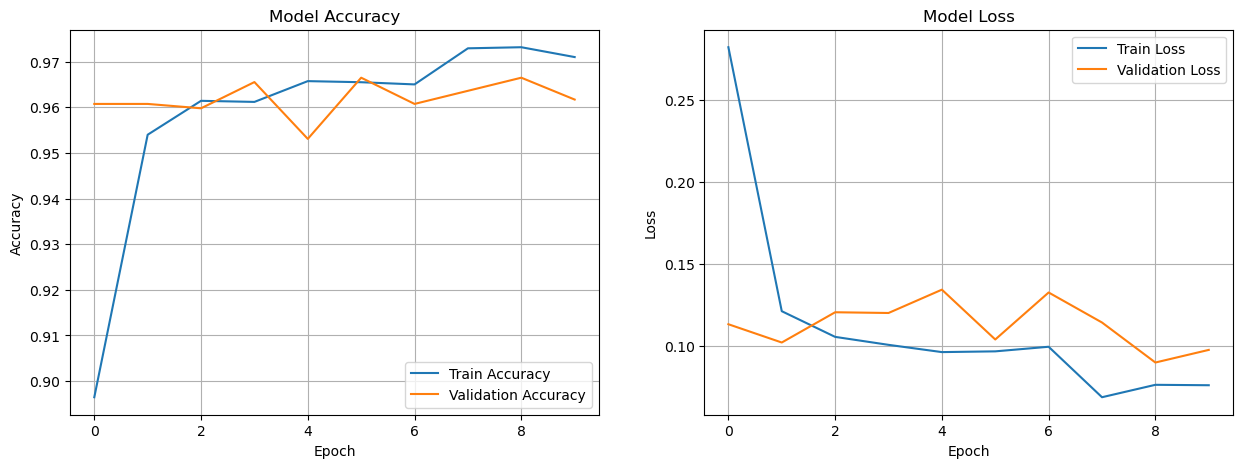

In [ ]:
plot_history(history_cnn)

In [ ]:
def get_predictions(model, data_loader):
    model.eval() # 평가 모드로 설정
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            # 예측값과 실제 정답을 CPU로 이동시켜 numpy 배열로 변환 후 리스트에 추가
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


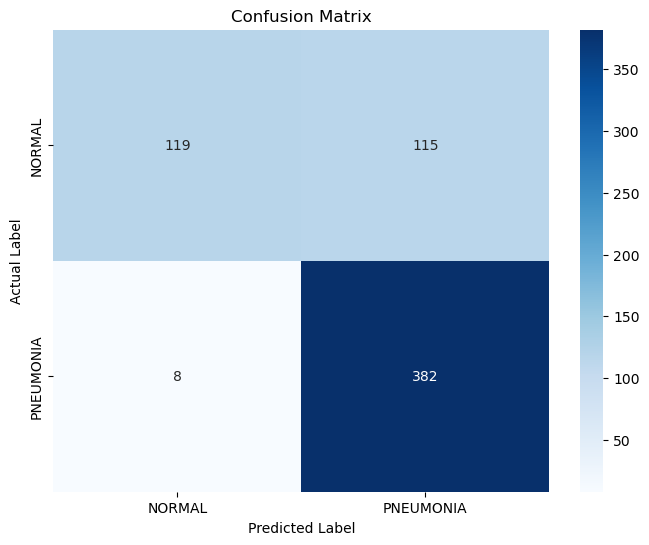

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix



# 테스트 데이터로 예측 실행
y_true, y_pred = get_predictions(trained_model_cnn, test_loader)

# 혼동 행렬 계산
cm = confusion_matrix(y_true, y_pred)

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## 2. 전이학습

1. 사전학습 (Pretraining)
    - 대규모 데이터셋에서 모델을 먼저 학습시켜 일반적인 특징(feature)을 익히는 단계
    - 예: ImageNet으로 학습된 ResNet, 대규모 텍스트로 학습된 BERT

2. 전이 (Transfer)
    - 학습된 모델을 새로운 문제에 적용하는 단계
    - 여기서 Frozen, Partial Fine-Tuning, Full Fine-Tuning 같은 방법을 선택
        - 1

3. 미세조정 (Fine-Tuning)
    - 새로운 데이터셋과 태스크에 맞춰 모델을 조정하는 단계
    - 데이터 크기와 유사성에 따라 일부 레이어만 조정하거나 전체를 학습

### 0) 사전학습

In [ ]:
import torchvision.models as models
import torch.optim as optim
import torch.nn as nn

# --- 1. 사전 학습된 ResNet18 모델 불러오기 --- # torchvision.models에서 ImageNet으로 미리 학습된 resnet18
model_ft = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

### 1) Frozen 모델

--- 전이학습 (Feature Extraction) 시작 ---


Epoch 1/10 - Train:   0%|          | 0/131 [00:00<?, ?it/s]

Epoch 1/10 - Val:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.2778 Acc: 0.8907 | Val Loss: 0.2152 Acc: 0.8975


Epoch 2/10 - Train:   0%|          | 0/131 [00:00<?, ?it/s]

...

Epoch 9/10 - Val:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.1402 Acc: 0.9453 | Val Loss: 0.1266 Acc: 0.9473


Epoch 10/10 - Train:   0%|          | 0/131 [00:00<?, ?it/s]

Epoch 10/10 - Val:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.1323 Acc: 0.9463 | Val Loss: 0.1191 Acc: 0.9483

--- 학습 결과 시각화 ---


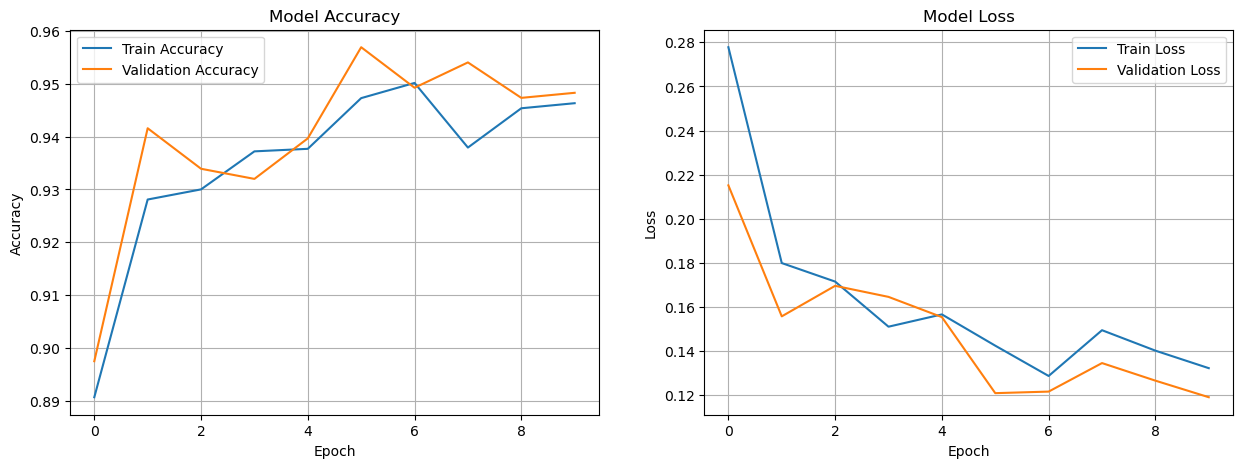

In [ ]:
# 이렇게 하면 기존의 지식(가중치)이 학습 중에 변경X
for param in model_ft.parameters():
    param.requires_grad = False

# --- 목적에 맞게 마지막 분류기(Classifier) 교체 ---
num_ftrs = model_ft.fc.in_features # 기존 분류기(fc layer)가 입력으로 받던 특징의 개수(512)를 알아냅니다.
model_ft.fc = nn.Linear(num_ftrs, num_classes) # 입력은 기존 규격(num_ftrs, 512)을 따르고, 출력은 우리 클래스 수(num_classes=2)에 맞춤.

# --- 모델을 사용할 장치(GPU/CPU)로 보내기 ---
model_ft = model_ft.to(device) # 개조된 모델 객체(model_ft)를 맨 처음에 설정한 장치(device)로 보냅니다.

# --- 5. 손실 함수와 옵티마이저 설정 ---
loss_fn = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(model_ft.fc.parameters(), lr=0.001)

# --- 6. 모델 학습 실행 ---
print("--- 전이학습 (Feature Extraction) 시작 ---")
model_ft, history_ft  = train_model(
    model=model_ft, # 바꿈
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn, # 바꿈
    optimizer=optimizer_ft, # 바꿈
    num_epochs=10
)

# return model, history = train_model(model, train_loader, val_loader, loss_fn, optimizer, num_epochs=10)
# --- 7. 학습 과정 시각화 ---
print("\n--- 학습 결과 시각화 ---")
plot_history(history_ft)

In [ ]:
# 테스트 데이터로 예측 실행
y_true_fr, y_pred_fr = get_predictions(model_ft, test_loader)

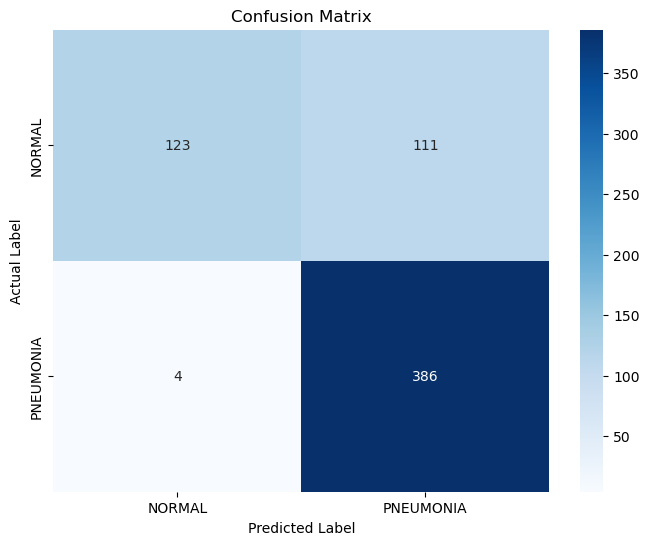

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 혼동 행렬 계산
cm = confusion_matrix(y_true_fr, y_pred_fr)

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### 2) Partial Fine-Tuning

--- 학습될 파라미터 목록 ---
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias

--- 전이학습 (Partial Fine-Tuning) 시작 ---


Epoch 1/10 - Train:   0%|          | 0/131 [00:00<?, ?it/s]

Epoch 1/10 - Val:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.1741 Acc: 0.9281 | Val Loss: 0.0918 Acc: 0.9713


Epoch 2/10 - Train:   0%|          | 0/131 [00:00<?, ?it/s]

...

Epoch 9/10 - Val:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0149 Acc: 0.9950 | Val Loss: 0.0586 Acc: 0.9799


Epoch 10/10 - Train:   0%|          | 0/131 [00:00<?, ?it/s]

Epoch 10/10 - Val:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0168 Acc: 0.9947 | Val Loss: 0.0618 Acc: 0.9837

--- 학습 결과 시각화 ---


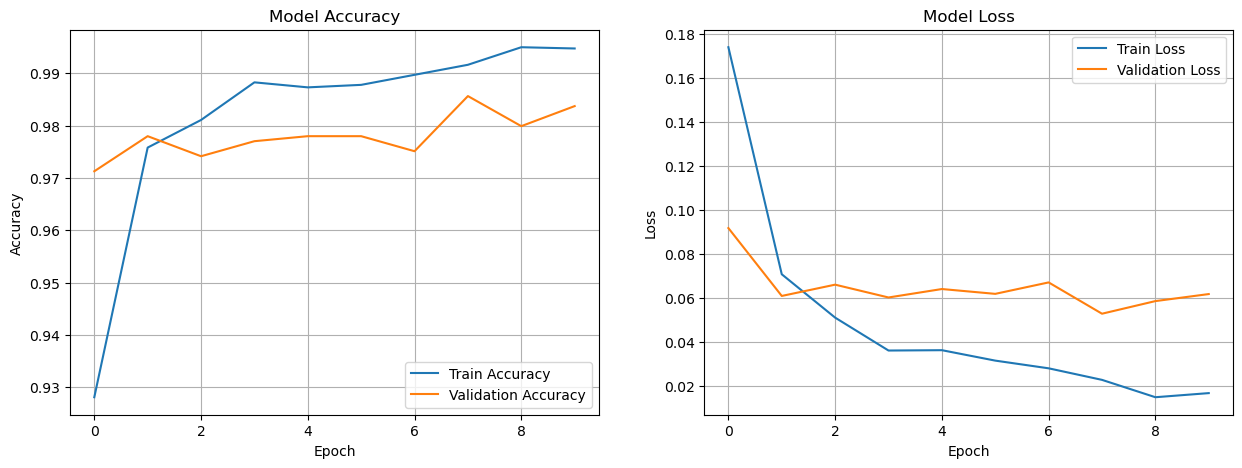

In [ ]:
import torchvision.models as models
import torch.optim as optim
import torch.nn as nn

# --- 사전 학습된 ResNet18 모델 다시 불러오기 ---
model_partial_ft = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# --- 모델의 일부 파라미터만 동결 해제 ---
# 모델의 모든 파라미터에서 이름 확인.
for name, param in model_partial_ft.named_parameters():
    # 마지막 블록('layer4')과 분류기('fc')의 파라미터만 학습하도록 설정합니다.
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        # 나머지 파라미터는 얼립니다.
        param.requires_grad = False

# --- 3. 목적에 맞게 마지막 분류기(Classifier) 교체 ---
num_ftrs = model_partial_ft.fc.in_features
model_partial_ft.fc = nn.Linear(num_ftrs, num_classes)
model_partial_ft = model_partial_ft.to(device)

# --- 4. 학습될 파라미터 확인 (선택 사항) ---
print("--- 학습될 파라미터 목록 ---")
for name, param in model_partial_ft.named_parameters():
    if param.requires_grad:
        print(name)

# --- 5. 손실 함수와 옵티마이저 설정 ---
loss_fn = nn.CrossEntropyLoss()

# 옵티마이저에 학습할 파라미터들만 전달합니다.
# param.requires_grad=True인 파라미터만 필터링합니다.
params_to_update = [p for p in model_partial_ft.parameters() if p.requires_grad]

# 학습률(lr)을 Feature Extraction 때보다 조금 낮춰서 미세 조정합니다.
optimizer_partial_ft = optim.Adam(params_to_update, lr=0.0001)

# --- 6. 모델 학습 실행 ---
print("\n--- 전이학습 (Partial Fine-Tuning) 시작 ---")
trained_partial_ft_model, history_partial = train_model(
    model=model_partial_ft,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer_partial_ft,
    num_epochs=10
)

# --- 7. 학습 과정 시각화 ---
print("\n--- 학습 결과 시각화 ---")
plot_history(history_partial)

In [ ]:
# 테스트 데이터로 예측 실행
y_true_pft, y_pred_pft = get_predictions(trained_partial_ft_model, test_loader)

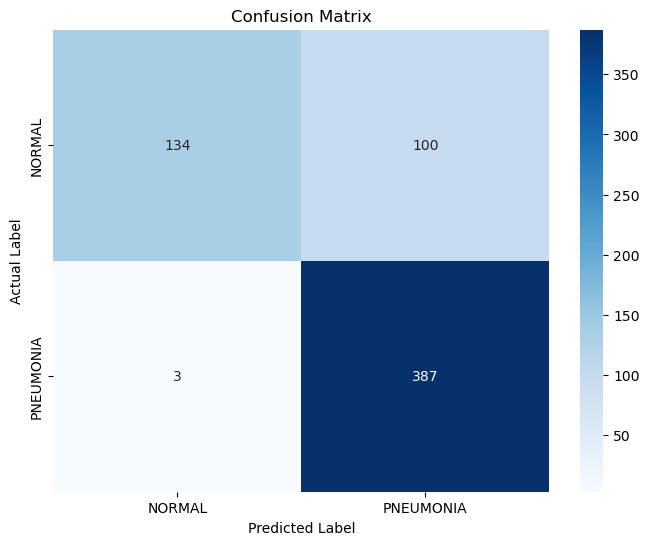

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 혼동 행렬 계산
cm = confusion_matrix(y_true_pft, y_pred_pft)

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### 3) Full Fine-Tuning


--- 전이학습 (Full Fine-Tuning) 시작 ---


Epoch 1/10 - Train:   0%|          | 0/131 [00:00<?, ?it/s]

Epoch 1/10 - Val:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.2332 Acc: 0.9322 | Val Loss: 0.1253 Acc: 0.9617


Epoch 2/10 - Train:   0%|          | 0/131 [00:00<?, ?it/s]

...

Epoch 9/10 - Val:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0341 Acc: 0.9871 | Val Loss: 0.0387 Acc: 0.9837


Epoch 10/10 - Train:   0%|          | 0/131 [00:00<?, ?it/s]

Epoch 10/10 - Val:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0270 Acc: 0.9928 | Val Loss: 0.0488 Acc: 0.9847

--- 학습 결과 시각화 ---


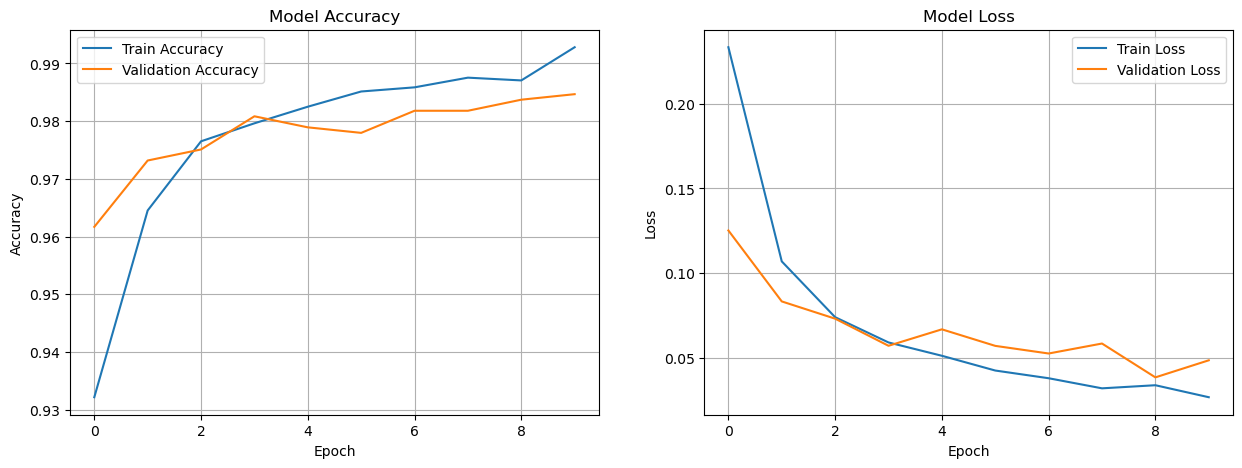

In [ ]:
import torchvision.models as models
import torch.optim as optim
import torch.nn as nn

# --- 1. 사전 학습된 ResNet18 모델 다시 불러오기 ---
model_full_ft = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# --- 2. 모델의 모든 파라미터 동결 해제 ---
# 모델을 불러오면 기본적으로 모든 파라미터가 학습 가능한 상태(requires_grad=True),

# --- 3. 목적에 맞게 마지막 분류기(Classifier) 교체 ---
num_ftrs = model_full_ft.fc.in_features
model_full_ft.fc = nn.Linear(num_ftrs, num_classes)
model_full_ft = model_full_ft.to(device)

# --- 4. 손실 함수와 옵티마이저 설정 ---
loss_fn = nn.CrossEntropyLoss()
# 이미 잘 학습된 가중치를 아주 조금씩만 미세하게 조정하기 위함입니다.
optimizer_full_ft = optim.Adam(model_full_ft.parameters(), lr=0.00001)

# --- 5. 모델 학습 실행 ---
print("\n--- 전이학습 (Full Fine-Tuning) 시작 ---")
trained_full_ft_model, history_full = train_model(
    model=model_full_ft,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer_full_ft,
    num_epochs=10
)

# --- 6. 학습 과정 시각화 ---
print("\n--- 학습 결과 시각화 ---")
plot_history(history_full)

In [ ]:
# 테스트 데이터로 예측 실행
y_true_fft, y_pred_fft = get_predictions(trained_full_ft_model, test_loader)

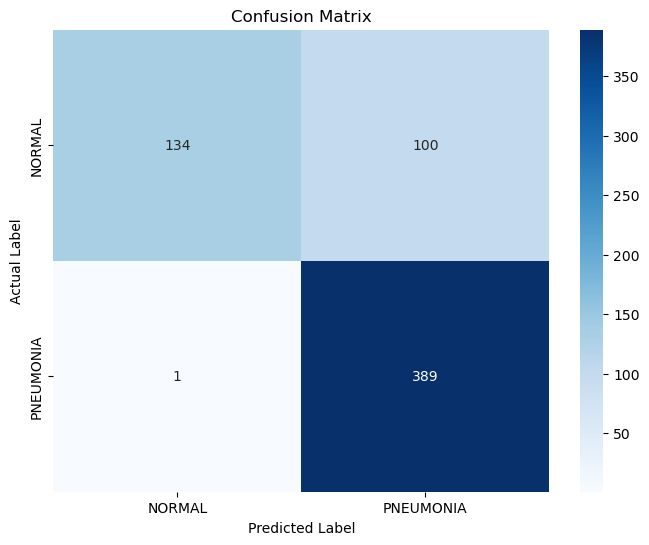

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 혼동 행렬 계산
cm = confusion_matrix(y_true_fft, y_pred_fft)

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 06. 결과 비교.

In [ ]:
import pandas as pd

# 비어있는 리스트를 먼저 만듭니다.
cm_list = []

# append()를 사용해 순서대로 추가합니다.
cm_list.append(confusion_matrix(y_true, y_pred))      # cm_list[0]에 저장됨
cm_list.append(confusion_matrix(y_true, y_pred_fr))   # cm_list[1]에 저장됨
cm_list.append(confusion_matrix(y_true, y_pred_pft))  # cm_list[2]에 저장됨
cm_list.append(confusion_matrix(y_true, y_pred_fft))  # cm_list[3]에 저장됨

# print(cm_list[0]) # 첫 번째 모델의 confusion matrix 출력


table_data = []
model_name = ["CNN (기본)", "Frozen", "Partial Tunning", "Full fine tuning"]
for i, cm in enumerate(cm_list):
    # cm.ravel()을 사용해 TN, FP, FN, TP 값을 순서대로 추출
    tn, fp, fn, tp = cm.ravel()
    table_data.append({
        "Model name": model_name[i],
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

df = pd.DataFrame(table_data)
print("--- ✅ 올바르게 생성된 표 ---")
print(df)

NameError: name 'y_true' is not defined

- 결론적으로 Full-fining tunning 이 가장 효과가 좋음. 따라서, Epoch 를 늘려서 진행하기로 함.

## 7. 최종 최적화 진행

In [ ]:
from tqdm.auto import tqdm # 학습 진행 상황을 시각적으로 보여주는 라이브러리

def train_model(model, train_loader, val_loader, loss_fn, optimizer, num_epochs):
    # epoch만큼 학습을 반복합니다.
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # --- 훈련 단계 ---
        model.train() # 모델을 '학습 모드'로 설정합니다.
        running_loss = 0.0
        running_corrects = 0

        # 데이터로더에서 미니배치(데이터 묶음)를 하나씩 꺼내와 학습합니다.
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Train"):
            inputs = inputs.to(device)  # 데이터를 설정된 장치(GPU/CPU)로 보냅니다.
            labels = labels.to(device)

            optimizer.zero_grad() # 이전 배치의 그래디언트(기울기)를 초기화합니다.

            outputs = model(inputs) # 모델에 입력을 넣어 예측값을 얻습니다.
            loss = loss_fn(outputs, labels) # 예측값과 실제 정답으로 손실을 계산합니다.

            _, preds = torch.max(outputs, 1) # 예측 결과 중 가장 확률이 높은 클래스를 선택합니다.

            loss.backward() # 손실을 역전파하여 각 파라미터의 그래디언트를 계산합니다.
            optimizer.step() # 계산된 그래디언트를 바탕으로 파라미터를 업데이트합니다.

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # 한 epoch의 평균 손실과 정확도를 계산합니다.
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.float() / len(train_loader.dataset)

        # --- 검증 단계 ---
        model.eval() # 모델을 '평가 모드'로 설정합니다.
        val_loss = 0.0
        val_corrects = 0

        # 평가 시에는 그래디언트 계산을 비활성화하여 메모리 사용량과 계산 속도를 높입니다.
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Val"):
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = loss_fn(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        # 한 epoch의 평균 검증 손실과 정확도를 계산합니다.
        val_epoch_loss = val_loss / len(val_loader.dataset)
        val_epoch_acc = val_corrects.float() / len(val_loader.dataset)

        # 결과 출력
        print(f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}")
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_epoch_acc.item())

    return model, history

In [ ]:
import torchvision.models as models
import torch.optim as optim
import torch.nn as nn
from tensorboardX import SummaryWriter

class_names = full_train_dataset.classes
num_classes = len(class_names)
model_full_ft = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = model_full_ft.fc.in_features
model_full_ft.fc = nn.Linear(num_ftrs, num_classes)
model_full_ft = model_full_ft.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer_full_ft = optim.Adam(model_full_ft.parameters(), lr=0.00001)

### 텐서보드 추가 (1/3): Writer 객체 생성 ###
# 'runs/full_fine_tuning' 폴더에 로그가 저장.
writer = SummaryWriter('runs/full_fine_tuning')



# --- 5. 모델 학습 실행 ---
print("\n--- 전이학습 (Full Fine-Tuning) 시작 ---")
trained_full_ft_model, history_full = train_model(
    model=model_full_ft,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer_full_ft,
    num_epochs=30,
)

# --- 6. 학습 과정 시각화 ---
print("\n--- TensorBoard 실행 방법 ---")
print("터미널을 열고 아래 명령어를 입력하세요:")
print("tensorboard --logdir=runs")


--- 전이학습 (Full Fine-Tuning) 시작 ---


Epoch 1/30 - Train:   0%|          | 0/131 [00:00<?, ?it/s]

Epoch 1/30 - Val:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.2760 Acc: 0.8955 | Val Loss: 0.1157 Acc: 0.9579


Epoch 2/30 - Train:   0%|          | 0/131 [00:00<?, ?it/s]

...

Epoch 29/30 - Val:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0090 Acc: 0.9974 | Val Loss: 0.0344 Acc: 0.9904


Epoch 30/30 - Train:   0%|          | 0/131 [00:00<?, ?it/s]

Epoch 30/30 - Val:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0067 Acc: 0.9988 | Val Loss: 0.0398 Acc: 0.9895

--- TensorBoard 실행 방법 ---
터미널을 열고 아래 명령어를 입력하세요:
tensorboard --logdir=runs


In [ ]:
def get_predictions(model, data_loader):
    model.eval() # 평가 모드로 설정
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            # 예측값과 실제 정답을 CPU로 이동시켜 numpy 배열로 변환 후 리스트에 추가
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


In [ ]:
# 테스트 데이터로 예측 실행
y_true_final, y_pred_final = get_predictions(trained_full_ft_model, test_loader)

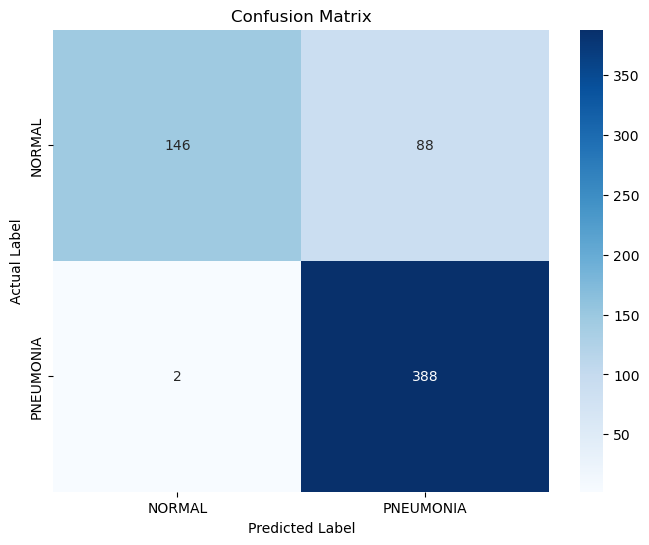

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 혼동 행렬 계산
cm = confusion_matrix(y_true_final, y_pred_final)

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
import pandas as pd

table_data=[]
tn, fp, fn, tp = cm.ravel()
table_data.append({
    "Metric": 'Full_Fine_Tunning',
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
})
print("\n--- 데이터프레임 결과 ---")
df = pd.DataFrame(table_data)
print(df.T)

accuracy = (tp + tn) / (tp + tn + fp + fn)

# 정밀도 (Precision) 계산
precision = tp / (tp + fp)

# 재현율 (Recall) 계산
recall = tp / (tp + fn)

# F1-점수 (F1-Score) 계산
f1_score = 2 * (precision * recall) / (precision + recall)

# 데이터프레임으로 결과 보기 (선택 사항)
scores_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1_score]
})
print("\n--- 데이터프레임 결과 ---")
print(scores_df)


--- 데이터프레임 결과 ---
                        0
Metric  Full_Fine_Tunning
TN                    146
FP                     88
FN                      2
TP                    388

--- 데이터프레임 결과 ---
      Metric     Score
0   Accuracy  0.855769
1  Precision  0.815126
2     Recall  0.994872
3   F1-Score  0.896074


결과적으로 다음과 같은 점수를 얻었다. 다만, 이가 좋은 정도의 점수인지는 감이 없다.
다만 문헌조사 결과 F1-Score 가 89점정도라면 괜찮은 성능이라고 확인할 수 있었따.

# 멘토코멘트

매우 체계적이고 전문적인 접근 방식을 보여주며, 특히 문제 해결 프로세스를 7단계로 명확히 정의한 점이 돋보입니다. 미션 소개부터 기본 데이터 입력 및 EDA, 전처리 및 증강, 드릴 다운, 모델링, 결과 시각화, 결과 생성에 이르기까지 논리적이고 구조적인 계획을 수립했습니다. PyTorch 기반의 전문적인 코드 작성과 함께 MPS, CUDA, CPU를 자동으로 선택하는 디바이스 최적화까지 고려한 점은 높은 기술적 역량을 보여줍니다.
  
주요 강점으로는 체계적인 문제 해결 프로세스, PyTorch 기반의 전문적인 코드 구현, 디바이스 최적화를 통한 효율적인 실행 환경 구축을 들 수 있습니다. 미션 소개 및 요구사항을 매우 상세하게 정리했으며, Frozen 모델, Partial Fine-Tuning, Full Fine-Tuning의 3가지 전략을 비교하는 명확한 평가 계획을 수립했습니다. Feature Importance 시각화 계획과 마크다운 작성 가이드까지 포함한 점은 프로젝트의 완성도를 높이는 요소입니다. torchvision transforms를 활용한 전처리와 Accuracy, Precision, Recall, F1-score 등 이진 분류 문제에 적절한 평가지표 선정도 우수합니다.
  
향후 발전을 위해서는 몇 가지 보완이 필요합니다. 실제 모델 훈련 결과를 구체적으로 제시하고, 3가지 Fine-Tuning 전략 비교를 통한 성능 개선 결과를 명확히 문서화할 필요가 있습니다. 코드 블록에 대한 주석을 보강하여 가독성을 높이고, 함수화를 통해 코드의 재사용성을 더욱 향상시킨다면 유지보수성이 개선될 것입니다. 또한 현재 계획된 EDA 외에 더 상세한 통계적 분석이나 시각적 EDA 결과를 추가한다면, 데이터에 대한 이해도를 더욱 명확하게 전달할 수 있을 것입니다. 전반적으로 매우 높은 수준의 이해도와 실행력을 갖춘 프로젝트이며, 위의 개선사항들이 보완된다면 완성도 있는 결과물이 될 것으로 기대됩니다.